<div style="text-align:center; font-family:Arial, sans-serif; background-color:#e8f3e6; padding:16px; border-radius:10px;">

### Series de Tiempo
#### Universidad Central — Maestría en Analítica de Datos
#### Docente: Wilson Sandoval Rodríguez — wsandovalr@ucentral.edu.co

## Cuadernillo 03 · Preparación de datos para series de tiempo

</div>

Este cuadernillo cubre el flujo completo de **preparación de una serie de tiempo** antes de modelarla: manejo del
índice temporal, remuestreo y cambio de frecuencia, elección de la función de agregación, transformaciones de
varianza (Box-Cox), diferenciación, variables de calendario, y detección/imputación de datos faltantes.


## 1. Objetivos de aprendizaje

Al finalizar este cuadernillo, el estudiante estará en capacidad de:

- Identificar y configurar correctamente un índice temporal (`DatetimeIndex`).
- Comprender qué es la frecuencia de una serie y cómo verificarla (`infer_freq`).
- Diferenciar conceptual y operativamente `asfreq()` de `resample()`.
- Realizar *downsampling* y, cuando corresponda, *upsampling*.
- Seleccionar adecuadamente una función de agregación según la naturaleza de la variable.
- Identificar cuándo una transformación de varianza puede ser necesaria y aplicar Box-Cox correctamente.
- Comprender el propósito y los riesgos de la diferenciación.
- Construir variables asociadas al calendario (día de semana, festivos, fin de mes, trimestre).
- Detectar datos faltantes y distinguir sus distintos orígenes.
- Comparar distintas estrategias de imputación con criterios objetivos (MAE, RMSE).
- Reconocer riesgos metodológicos: pérdida de información, sesgo de agregación y fuga de información temporal
  (*data leakage*).

## 2. Preparación del entorno

Todas las librerías que se usan en el cuadernillo se importan **una sola vez**, aquí. Si en su máquina falta
alguna, ejecute la celda de instalación (está comentada por defecto).

| Librería | Uso en este cuadernillo |
|---|---|
| `pandas` / `numpy` | manejo de series, índices temporales y cálculos numéricos |
| `matplotlib` / `seaborn` | visualización |
| `yfinance` | descarga de precios diarios de Litecoin (con respaldo simulado si falla) |
| `holidays` | festivos oficiales de Colombia |
| `scipy.stats.boxcox` | transformación de estabilización de varianza |
| `statsmodels` | modelo ARIMA usado como método de imputación |

In [1]:
# %pip install pandas numpy matplotlib seaborn yfinance holidays scipy statsmodels

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from scipy.stats import boxcox
from statsmodels.tsa.arima.model import ARIMA

try:
    import yfinance as yf
    YFINANCE_DISPONIBLE = True
except ImportError:
    YFINANCE_DISPONIBLE = False

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")

np.random.seed(42)
sns.set_style("darkgrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "bold"

%matplotlib inline


def formatear_grafico(ax, titulo, ylabel, xlabel="Fecha"):
    # Aplica un estilo uniforme (título, ejes, cuadrícula, leyenda) a un eje de matplotlib.
    ax.set_title(titulo)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    handles, _ = ax.get_legend_handles_labels()
    if handles:
        ax.legend()
    return ax


print("Entorno listo. Semilla aleatoria fijada en 42 para reproducibilidad.")

Entorno listo. Semilla aleatoria fijada en 42 para reproducibilidad.


> ⚠️ **Cuidado — reproducibilidad**
> Fijar la semilla (`np.random.seed(42)`) garantiza que los datos *simulados* de este cuadernillo sean siempre
> los mismos. No garantiza que los datos *descargados* (Yahoo Finance, repositorio del curso) sean idénticos si
> la fuente cambia; por eso cada descarga usa fechas fijas y, si falla, cae a una alternativa local reproducible.

## 3. Manejo del índice temporal

### Concepto

Una serie de tiempo en pandas es solo un `Series`/`DataFrame` cuyo índice es un `DatetimeIndex`: un arreglo de
fechas ordenado que le da a pandas la capacidad de saber "qué sigue temporalmente" a cada observación. Sin un
índice temporal correcto, operaciones como `resample()`, `asfreq()`, `diff()` con lags temporales o los modelos
de la librería `statsmodels` no funcionan de forma confiable.

### ¿Para qué sirve?

Un índice temporal bien construido permite:

- Ordenar cronológicamente sin ambigüedad.
- Detectar automáticamente la frecuencia (`pd.infer_freq`).
- Revelar fechas faltantes al forzar una frecuencia regular con `asfreq()`.
- Alinear correctamente varias series entre sí.

### Ejemplo

Construimos a propósito una mini-serie con un **duplicado** y **fechas faltantes** para ver cómo se detectan.

In [3]:
fechas_ejemplo = pd.to_datetime(
    ["2024-01-02", "2024-01-01", "2024-01-02", "2024-01-04", "2024-01-06"]
)
valores_ejemplo = [12, 10, 12, 15, 18]

serie_ejemplo = pd.Series(valores_ejemplo, index=fechas_ejemplo, name="valor")
serie_ejemplo

2024-01-02    12
2024-01-01    10
2024-01-02    12
2024-01-04    15
2024-01-06    18
Name: valor, dtype: int64

### 🔎 Interpretación

El índice no está ordenado (2024-01-02 aparece antes que 2024-01-01) y la fecha `2024-01-02` está **duplicada**.
Además faltan los días 3 y 5 de enero. Ninguno de estos problemas es visible a simple vista en una tabla; hay que
verificarlos explícitamente.

In [4]:
print("¿Índice ordenado?:", serie_ejemplo.index.is_monotonic_increasing)
print("Duplicados en el índice:", serie_ejemplo.index.duplicated().sum())

# Corregir: ordenar y eliminar duplicados (conservando la primera ocurrencia)
serie_ejemplo = serie_ejemplo.sort_index()
serie_ejemplo = serie_ejemplo[~serie_ejemplo.index.duplicated(keep="first")]

print("\nFrecuencia inferida (índice irregular):", pd.infer_freq(serie_ejemplo.index))

# Forzar una frecuencia diaria regular revela las fechas ausentes como NaN
serie_regular = serie_ejemplo.asfreq("D")
serie_regular

¿Índice ordenado?: False
Duplicados en el índice: 1

Frecuencia inferida (índice irregular): None


2024-01-01    10.0
2024-01-02    12.0
2024-01-03     NaN
2024-01-04    15.0
2024-01-05     NaN
2024-01-06    18.0
Freq: D, Name: valor, dtype: float64

### 🔎 Interpretación

`pd.infer_freq()` devuelve `None` porque, con fechas faltantes, pandas no puede confirmar un patrón regular. Al
forzar `asfreq('D')`, las fechas que no existían en los datos originales (3 y 5 de enero) aparecen explícitamente
como `NaN`. Esto es distinto de un valor que **es cero**: es un hueco en el calendario. Retomaremos esta
distinción en la sección 10.

> ⚠️ **Cuidado**
> `resample()` y muchos modelos de `statsmodels` asumen una frecuencia regular. Si no la fuerza explícitamente
> con `asfreq()` o `resample()`, pandas puede inferir una frecuencia incorrecta o el modelo puede fallar
> silenciosamente.

### 🧠 Para pensar

1. ¿Por qué `pd.infer_freq()` necesita al menos 3 observaciones consecutivas y regulares para funcionar?
2. Si una serie tiene una fecha duplicada con dos valores distintos, ¿cuál cree que es más razonable: promediar,
   sumar, o quedarse con el primero? ¿Depende del contexto?

### ✍️ Ejercicio

Cree una serie de 6 fechas semanales (`freq="W"`) a partir del 2024-01-01, elimine manualmente la tercera fecha
del índice (simulando un dato faltante) y verifique con `pd.infer_freq()` si pandas aún reconoce la frecuencia
semanal.

## 4. Remuestreo y cambio de frecuencia

### Concepto

*Remuestrear* es representar una serie con una frecuencia distinta a la original. Si tenemos precios diarios y
solo necesitamos una vista mensual, agregamos ("downsampling"); si tenemos datos mensuales y queremos una grilla
diaria, los completamos ("upsampling") sin crear información nueva.

### ¿Para qué sirve?

- Reducir ruido de corto plazo y resaltar tendencia (downsampling).
- Adaptar la frecuencia de varias series distintas a una frecuencia común antes de combinarlas.
- Cumplir con el requisito de frecuencia regular que exigen los modelos ARIMA/SARIMA.

### Datos de ejemplo: Litecoin (Yahoo Finance)

Usamos precios diarios de Litecoin (`LTC-USD`) como ejemplo de una serie financiera real. Para que la clase sea
reproducible:

- Se fija un rango de fechas exacto (`start`/`end`) en lugar de `period="5y"`, que cambiaría cada vez que se
  ejecute el notebook en una fecha distinta.
- La descarga se hace **una sola vez** y el resultado se reutiliza en el resto del cuadernillo (el notebook
  original repetía la descarga en 5 celdas distintas).
- Si no hay conexión a internet, se genera automáticamente una serie simulada con propiedades similares
  (caminata aleatoria geométrica con semilla fija), para que el resto del notebook siga funcionando.

In [5]:
def cargar_serie_cripto(ticker="LTC-USD", inicio="2020-01-01", fin="2025-12-31", semilla=42):
    # Descarga precios diarios OHLC de Yahoo Finance; si falla, simula una serie comparable.
    if YFINANCE_DISPONIBLE:
        try:
            datos = yf.download(ticker, start=inicio, end=fin, interval="1d",
                                 progress=False, auto_adjust=True)
            if datos.empty:
                raise ValueError("la descarga no devolvió datos")
            if isinstance(datos.columns, pd.MultiIndex):
                datos.columns = datos.columns.get_level_values(0)
            datos.index = pd.to_datetime(datos.index)
            datos = datos[~datos.index.duplicated(keep="first")].sort_index()
            print(f"Fuente de datos: Yahoo Finance ({len(datos)} observaciones de {ticker}).")
            return datos[["Open", "High", "Low", "Close"]], "yfinance"
        except Exception as error:
            print(f"No fue posible descargar datos de Yahoo Finance ({error}).")
    print("Se genera una serie simulada con propiedades similares (semilla fija) para continuar la clase.")
    rng = np.random.default_rng(semilla)
    fechas = pd.date_range(inicio, fin, freq="D")
    rendimientos = rng.normal(loc=0.0003, scale=0.045, size=len(fechas))
    cierre = 60 * np.exp(np.cumsum(rendimientos))
    apertura = cierre * (1 + rng.normal(0, 0.01, len(fechas)))
    maximo = np.maximum(apertura, cierre) * (1 + np.abs(rng.normal(0, 0.01, len(fechas))))
    minimo = np.minimum(apertura, cierre) * (1 - np.abs(rng.normal(0, 0.01, len(fechas))))
    datos = pd.DataFrame({"Open": apertura, "High": maximo, "Low": minimo, "Close": cierre}, index=fechas)
    return datos, "simulado"


df_ltc, fuente_ltc = cargar_serie_cripto()
serie_ltc = df_ltc[["Open"]].asfreq("D")
serie_ltc.tail()


1 Failed download:
['LTC-USD']: TypeError("'NoneType' object is not subscriptable")


No fue posible descargar datos de Yahoo Finance (la descarga no devolvió datos).
Se genera una serie simulada con propiedades similares (semilla fija) para continuar la clase.


,Open
2025-12-27,0.889925
2025-12-28,1.006790
2025-12-29,1.015753
2025-12-30,1.051504
2025-12-31,0.996947


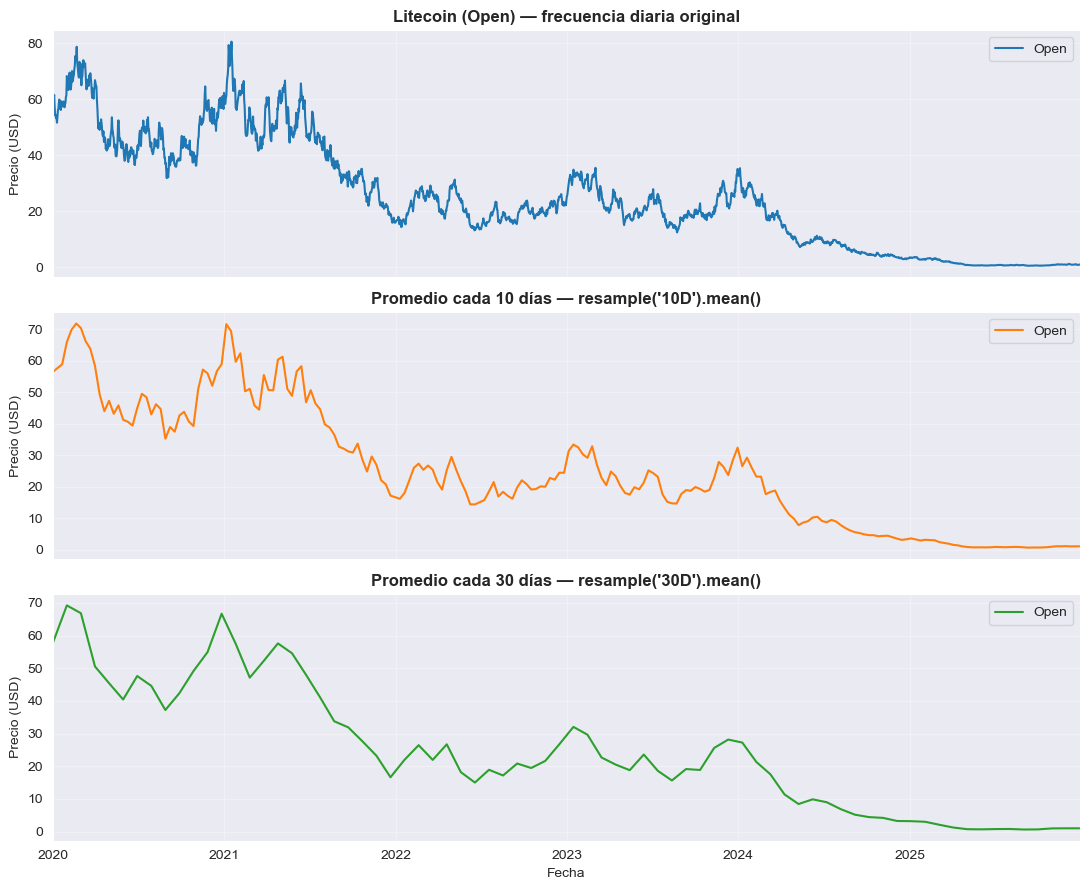

In [6]:
fig, ejes = plt.subplots(3, 1, sharex=True, figsize=(11, 9))

serie_ltc.plot(ax=ejes[0], legend=False)
formatear_grafico(ejes[0], "Litecoin (Open) — frecuencia diaria original", "Precio (USD)")

serie_ltc.resample("10D").mean().plot(ax=ejes[1], legend=False, color="tab:orange")
formatear_grafico(ejes[1], "Promedio cada 10 días — resample('10D').mean()", "Precio (USD)")

serie_ltc.resample("30D").mean().plot(ax=ejes[2], legend=False, color="tab:green")
formatear_grafico(ejes[2], "Promedio cada 30 días — resample('30D').mean()", "Precio (USD)")

plt.tight_layout()
plt.show()

### 🔎 Interpretación

A medida que se reduce la frecuencia (downsampling), la serie se suaviza: se pierde variabilidad de corto plazo
y se resalta la tendencia estructural. Esto **no** significa que la serie mensual sea "mejor"; significa que
responde una pregunta distinta (tendencia de mediano plazo en vez de fluctuación diaria).

### 🧠 Para pensar

1. Si el objetivo del análisis es detectar movimientos bruscos de corto plazo (por ejemplo, una caída súbita),
   ¿conviene trabajar con la serie diaria o con la mensual?
2. ¿Qué información se pierde irreversiblemente al pasar de datos diarios a promedios de 30 días?

### ✍️ Ejercicio

Usando `serie_ltc`, calcule el remuestreo semanal (`'W'`) con la función `.max()` en lugar de `.mean()`.
¿Cambia la forma general de la serie? ¿Por qué elegir el máximo puede ser razonable en un contexto financiero?

## 5. `asfreq()` vs `resample()`

### Concepto

Ambos métodos cambian la frecuencia de una serie, pero hacen cosas conceptualmente distintas:

- **`asfreq(freq)`**: reindexa la serie a la nueva frecuencia y **selecciona** (no agrega) el valor que cae en
  cada fecha del nuevo calendario. Si no hay observación exacta en esa fecha, el resultado es `NaN` (salvo que
  se indique un método de relleno).
- **`resample(freq).funcion()`**: agrupa las observaciones que caen dentro de cada intervalo y les aplica una
  función de agregación (`mean`, `sum`, `last`, ...).

> ⚠️ **Cuidado**
> Cambiar la frecuencia **no es sinónimo de agregar observaciones**. `asfreq('10D')` cambia la frecuencia sin
> agregar nada; solo `resample('10D').mean()` (u otra función) agrega.

### Ejemplo

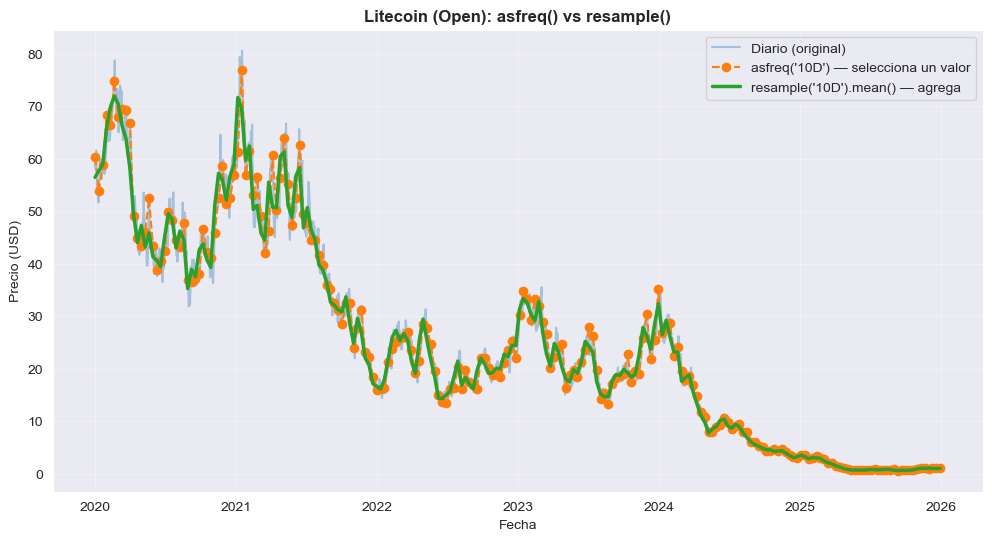

In [7]:
asfreq_10d = serie_ltc.asfreq("10D")
resample_10d = serie_ltc.resample("10D").mean()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(serie_ltc, label="Diario (original)", alpha=0.35)
ax.plot(asfreq_10d, marker="o", linestyle="--", label="asfreq('10D') — selecciona un valor")
ax.plot(resample_10d, linewidth=2.5, label="resample('10D').mean() — agrega")
formatear_grafico(ax, "Litecoin (Open): asfreq() vs resample()", "Precio (USD)")
plt.show()

### 🔎 Interpretación

`asfreq('10D')` conserva el valor exacto de un día cada 10 (una muestra puntual, más "ruidosa"). `resample('10D
').mean()` promedia los 10 días, produciendo una curva más suave porque combina información de todo el intervalo.
Ambas series tienen la misma cantidad de puntos, pero representan cosas distintas.

| Característica | `asfreq()` | `resample()` |
|---|---|---|
| ¿Agrega datos? | No | Sí |
| ¿Cambia los valores originales? | No (solo selecciona) | Sí (media, suma, etc.) |
| Efecto sobre la varianza | Prácticamente ninguno | La reduce |
| Uso típico | Forzar una frecuencia fija sin alterar valores | Suavizar / resumir para análisis de tendencia |
| Riesgo principal | Perder observaciones que no caen justo en la nueva grilla | Introducir sesgo de agregación |

### Errores frecuentes

- Usar `asfreq()` esperando que promedie: no lo hace, solo reindexa.
- Usar `resample().mean()` sobre variables donde la suma o el último valor tienen más sentido (ver sección 6).
- Olvidar `.asfreq('D')` antes de comparar series y terminar comparando índices con distinta frecuencia implícita.

### 🧠 Para pensar

1. ¿Qué diferencia conceptual existe entre `asfreq('ME')` y `resample('ME').mean()`?
2. ¿En qué escenario `asfreq()` podría *perder* una observación importante que `resample()` sí capturaría?

### ✍️ Ejercicio

Calcule `serie_ltc.asfreq('7D')` y `serie_ltc.resample('7D').last()`. Compare ambos resultados: ¿en qué se
parecen y en qué se diferencian? (Pista: piense en qué día de la semana cae cada corte).

## 6. Elección de la función de agregación

### Concepto

`resample()` necesita una función de agregación, y `.mean()` no siempre es la correcta. La función adecuada
depende de **qué representa la variable**:

| Variable | Función típica | Razón |
|---|---|---|
| Ventas, unidades vendidas | `.sum()` | Son flujos: lo relevante es el total del periodo |
| Temperatura, humedad | `.mean()` | Son variables de estado promediables |
| Inventario, saldo de cuenta | `.last()` | Es un nivel: importa el valor al cierre del periodo |
| Precio de apertura (`Open`) | `.first()` | El primer valor observado en el periodo |
| Precio máximo/mínimo intradía | `.max()` / `.min()` | Extremos del periodo |
| Precio de cierre financiero | depende del objetivo (`.last()` para nivel, `.mean()` para promedio) | Ambas lecturas son válidas; hay que ser explícito |

> ⚠️ **Cuidado**
> Usar `.mean()` por defecto en variables de tipo "flujo" (ventas, unidades) **subestima sistemáticamente** el
> total del periodo. Usar `.sum()` en variables de "nivel" (inventario, temperatura) produce un número sin
> sentido económico.

### Ejemplo con datos OHLC de Litecoin

`df_ltc` tiene las 4 columnas típicas de un activo financiero: `Open`, `High`, `Low`, `Close`. Al remuestrear a
mensual, cada una necesita una función distinta.

In [8]:
mensual_ohlc = df_ltc.resample("ME").agg({
    "Open": "first",
    "High": "max",
    "Low": "min",
    "Close": "last",
})
mensual_ohlc.head()

,Open,High,Low,Close
2020-01-31,60.238708,68.389850,51.465055,68.218635
2020-02-29,66.470415,79.393183,62.094912,72.865503
2020-03-31,68.027697,74.992592,59.332229,66.069242
2020-04-30,65.979048,66.317253,41.504927,42.880491
2020-05-31,43.264984,53.707559,38.888624,42.297295


### 🔎 Interpretación

`Open` mensual es el precio del **primer** día de cada mes, `Close` mensual es el del **último**, y `High`/`Low`
son los extremos observados durante todo el mes. Ninguna de las cuatro se calcula con `.mean()`: promediar
precios de apertura, por ejemplo, no representaría ni el nivel inicial ni el final del mes.

### Ejemplo adicional: ventas (suma) vs temperatura (media)

In [9]:
fechas_dia = pd.date_range("2024-01-01", periods=90, freq="D")
ventas_diarias = pd.Series(np.random.default_rng(1).poisson(lam=40, size=90), index=fechas_dia, name="ventas")
temperatura_diaria = pd.Series(18 + 4 * np.sin(np.arange(90) / 6) + np.random.default_rng(2).normal(0, 0.5, 90),
                                index=fechas_dia, name="temperatura")

ventas_mensuales_correcto = ventas_diarias.resample("ME").sum()
ventas_mensuales_incorrecto = ventas_diarias.resample("ME").mean()
temperatura_mensual = temperatura_diaria.resample("ME").mean()

comparacion = pd.DataFrame({
    "Ventas: suma (correcto)": ventas_mensuales_correcto,
    "Ventas: media (incorrecto para un total)": ventas_mensuales_incorrecto,
    "Temperatura: media (correcto)": temperatura_mensual,
})
comparacion

,Ventas: suma (correcto),Ventas: media (incorrecto para un total),Temperatura: media (correcto)
2024-01-31,1244,40.129032,18.468439
2024-02-29,1168,40.275862,19.137450
2024-03-31,1219,40.633333,17.809074


### 🔎 Interpretación

La columna "Ventas: media" reporta un número ~40 (el promedio diario), no el total mensual (~1200 unidades). Si
el objetivo es reportar ventas totales del mes, usar `.mean()` da una cifra equivocada por un factor cercano al
número de días del mes. Para la temperatura, en cambio, la media diaria sí es la agregación correcta: no existe
un "total de temperatura" con sentido físico.

### 🧠 Para pensar

1. ¿Utilizaría `.mean()` o `.sum()` para pasar ventas diarias a ventas mensuales? ¿Por qué?
2. Para una serie de inventario (nivel de stock al cierre del día), ¿qué problema tendría usar `.sum()` mensual?

### ✍️ Ejercicio

Simule una serie de "saldo de cuenta bancaria" diario (por ejemplo, un paseo aleatorio alrededor de 1,000,000)
y conviértala a saldo mensual usando la función de agregación que considere correcta. Justifique la elección en
una frase.

## 7. Transformaciones para estabilizar la varianza

### Concepto

Muchos modelos de series de tiempo (ARIMA, regresión) suponen varianza aproximadamente constante en el tiempo
(homocedasticidad). Cuando la varianza crece junto con el nivel de la serie —muy común en datos económicos y de
producción—, conviene aplicar una transformación que la estabilice antes de modelar.

La transformación de **Box-Cox** es la herramienta más común para esto. Para una serie $\{y_t\}$, estrictamente
positiva, la serie transformada $\{w_t\}$ es:

$$
w_t=\begin{cases}
\log(y_t), & \lambda=0 \\[4pt]
\dfrac{y_{t}^{\lambda} - 1}{\lambda}, & \lambda\neq 0
\end{cases}
$$

**Casos particulares de $\lambda$:**

| $\lambda$ | Transformación equivalente |
|---|---|
| $1$ | Ninguna (salvo un desplazamiento y escala) |
| $1/2$ | Raíz cuadrada |
| $0$ | Logaritmo natural |
| $-1$ | Inversa ($1/y_t$) |

> ⚠️ **Cuidado**
> Box-Cox **requiere valores estrictamente positivos**. Si la serie tiene ceros o negativos, la transformación
> no está definida. Desplazar artificialmente los datos (sumar una constante) para forzar positividad es una
> decisión de modelado que cambia la interpretación de la serie y debe documentarse explícitamente — no aplicarse
> de forma automática y silenciosa.

### Datos de ejemplo: producción mensual de gas en Australia (1956–1995)

Se intenta primero la descarga desde el repositorio del curso; si falla, se usa una copia local incluida en el
notebook para no interrumpir la clase.

No fue posible descargar el archivo remoto (<urlopen error [WinError 10060] Se produjo un error durante el intento de conexión ya que la parte conectada no respondió adecuadamente tras un periodo de tiempo, o bien se produjo un error en la conexión establecida ya que el host conectado no ha podido responder>). Se usa la copia local incluida en el notebook.


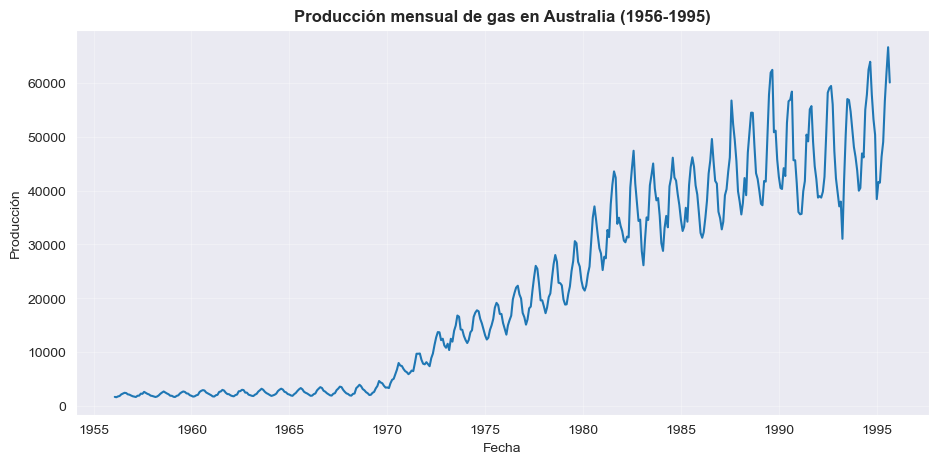

In [10]:
GAS_AUSTRALIA_RESPALDO = [1709, 1646, 1794, 1878, 2173, 2321, 2468, 2416, 2184, 2121, 1962, 1825, 1751, 1688, 1920, 1941, 2311, 2279, 2638, 2448, 2279, 2163, 1941, 1878, 1773, 1688, 1783, 1984, 2290, 2511, 2712, 2522, 2342, 2195, 1931, 1910, 1730, 1688, 1899, 1994, 2342, 2553, 2712, 2627, 2363, 2311, 2026, 1910, 1762, 1815, 2005, 2089, 2617, 2828, 2965, 2891, 2532, 2363, 2216, 2026, 1804, 1773, 2015, 2089, 2627, 2712, 3007, 2880, 2490, 2237, 2205, 1984, 1868, 1815, 2047, 2142, 2743, 2775, 3028, 2965, 2501, 2501, 2131, 2015, 1910, 1868, 2121, 2268, 2690, 2933, 3218, 3028, 2659, 2406, 2258, 2057, 1889, 1984, 2110, 2311, 2785, 3039, 3229, 3070, 2659, 2543, 2237, 2142, 1962, 1910, 2216, 2437, 2817, 3123, 3345, 3112, 2659, 2469, 2332, 2110, 1910, 1941, 2216, 2342, 2923, 3229, 3513, 3355, 2849, 2680, 2395, 2205, 1994, 1952, 2290, 2395, 2965, 3239, 3608, 3524, 3018, 2648, 2363, 2247, 1994, 1941, 2258, 2332, 3323, 3608, 3957, 3672, 3155, 2933, 2585, 2384, 2057, 2100, 2458, 2638, 3292, 3724, 4652, 4379, 4231, 3756, 3429, 3461, 3345, 4220, 4874, 5064, 5951, 6774, 7997, 7523, 7438, 6879, 6489, 6288, 5919, 6183, 6594, 6489, 8040, 9715, 9714, 9756, 8595, 7861, 7753, 8154, 7778, 7402, 8903, 9742, 11372, 12741, 13733, 13691, 12239, 12502, 11241, 10829, 11569, 10397, 12493, 11962, 13974, 14945, 16805, 16587, 14225, 14157, 13016, 12253, 11704, 12275, 13695, 14082, 16555, 17339, 17777, 17592, 16194, 15336, 14208, 13116, 12354, 12682, 14141, 14989, 16159, 18276, 19157, 18737, 17109, 17094, 15418, 14312, 13260, 14990, 15975, 16770, 19819, 20983, 22001, 22337, 20750, 19969, 17293, 16498, 15117, 16058, 18137, 18471, 21398, 23854, 26025, 25479, 22804, 19619, 19627, 18488, 17243, 18284, 20226, 20903, 23768, 26323, 28038, 26776, 22886, 22813, 22404, 19795, 18839, 18892, 20823, 22212, 25076, 26884, 30611, 30228, 26762, 25885, 23328, 21930, 21433, 22369, 24503, 25905, 30605, 34984, 37060, 34502, 31793, 29275, 28305, 25248, 27730, 27424, 32684, 31366, 37459, 41060, 43558, 42398, 33827, 34962, 33480, 32445, 30715, 30400, 31451, 31306, 40592, 44133, 47387, 41310, 37913, 34355, 34607, 28729, 26138, 30745, 35018, 34549, 40980, 42869, 45022, 40387, 38180, 38608, 35308, 30234, 28801, 33034, 35294, 33181, 40797, 42355, 46098, 42430, 41851, 39331, 37328, 34514, 32494, 33308, 36805, 34221, 41020, 44350, 46173, 44435, 40943, 39269, 35901, 32142, 31239, 32261, 34951, 38109, 43168, 45547, 49568, 45387, 41805, 41281, 36068, 34879, 32791, 34206, 39128, 40249, 43519, 46137, 56709, 52306, 49397, 45500, 39857, 37958, 35567, 37696, 42319, 39137, 47062, 50610, 54457, 54435, 48516, 43225, 42155, 39995, 37541, 37277, 41778, 41666, 49616, 57793, 61884, 62400, 50820, 51116, 45731, 42528, 40459, 40295, 44147, 42697, 52561, 56572, 56858, 58363, 45627, 45622, 41304, 36016, 35592, 35677, 39864, 41761, 50380, 49129, 55066, 55671, 49058, 44503, 42145, 38698, 38963, 38690, 39792, 42545, 50145, 58164, 59035, 59408, 55988, 47321, 42269, 39606, 37059, 37963, 31043, 41712, 50366, 56977, 56807, 54634, 51367, 48073, 46251, 43736, 39975, 40478, 46895, 46147, 55011, 57799, 62450, 63896, 57784, 53231, 50354, 38410, 41600, 41471, 46287, 49013, 56624, 61739, 66600, 60054]


def cargar_gas_australia():
    # Descarga la producción mensual de gas en Australia; si falla, usa una copia local.
    url = "https://github.com/Wilsonsr/Series-de-Tiempo/raw/main/03_datos/compartidos/gas.csv"
    try:
        datos = pd.read_csv(url, delimiter=";", decimal=",", index_col=0)
        valores = datos.iloc[:, 0].astype(float).values
        print(f"Fuente de datos: repositorio del curso ({len(valores)} observaciones).")
    except Exception as error:
        print(f"No fue posible descargar el archivo remoto ({error}). Se usa la copia local incluida en el notebook.")
        valores = np.array(GAS_AUSTRALIA_RESPALDO, dtype=float)
    fechas = pd.date_range(start="1956-01-01", periods=len(valores), freq="ME")
    return pd.Series(valores, index=fechas, name="produccion_gas")


serie_gas = cargar_gas_australia()

fig, ax = plt.subplots()
ax.plot(serie_gas, color="tab:blue")
formatear_grafico(ax, "Producción mensual de gas en Australia (1956-1995)", "Producción")
plt.show()

### 🔎 Interpretación

La amplitud de las oscilaciones estacionales crece notablemente a partir de mediados de los años 70, al mismo
tiempo que crece el nivel de la serie: es el patrón clásico de **varianza no constante relacionada con el
nivel**, el síntoma que Box-Cox busca corregir.

Lambda óptimo (máxima verosimilitud): 0.1924


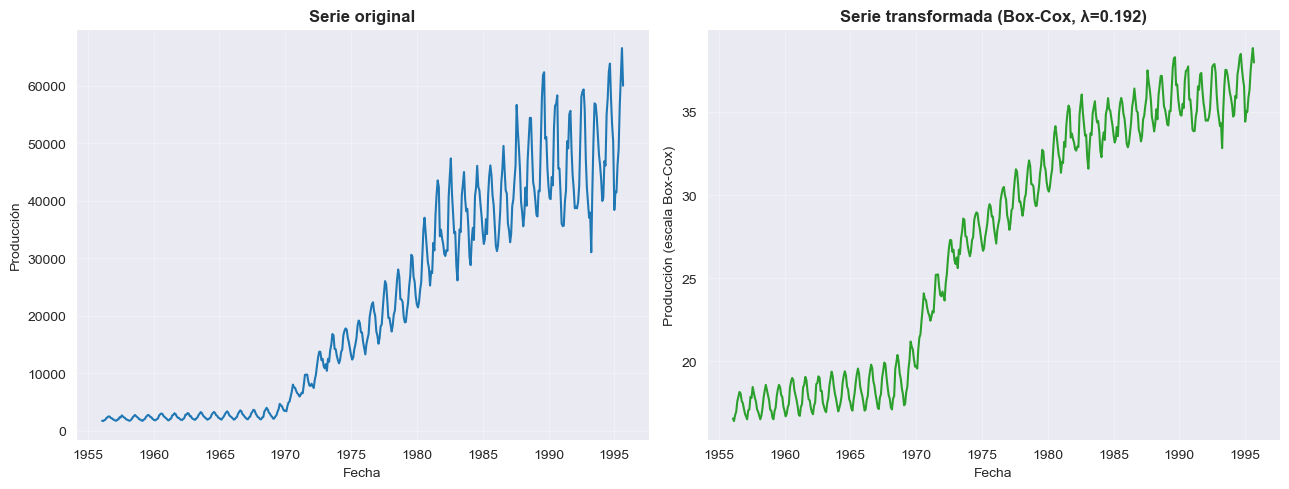

In [11]:
assert (serie_gas > 0).all(), "Box-Cox requiere valores estrictamente positivos."

valores_transformados, lambda_optimo = boxcox(serie_gas.values)

# Mantenemos el índice temporal original: NO se descarta la fecha al transformar.
serie_gas_boxcox = pd.Series(valores_transformados, index=serie_gas.index, name="produccion_gas_boxcox")

print(f"Lambda óptimo (máxima verosimilitud): {lambda_optimo:.4f}")

fig, ejes = plt.subplots(1, 2, figsize=(13, 5))
ejes[0].plot(serie_gas)
formatear_grafico(ejes[0], "Serie original", "Producción")
ejes[1].plot(serie_gas_boxcox, color="tab:green")
formatear_grafico(ejes[1], f"Serie transformada (Box-Cox, λ={lambda_optimo:.3f})", "Producción (escala Box-Cox)")
plt.tight_layout()
plt.show()

### 🔎 Interpretación

Con $\lambda \approx 0.19$ (cercano a 0), la transformación se comporta de forma similar a un logaritmo: reduce
la escala de las oscilaciones grandes de los últimos años, dejando una amplitud estacional más comparable entre
el inicio y el final de la serie. Nótese que `serie_gas_boxcox` conserva el **índice de fechas original** — a
diferencia de una implementación ingenua que devolvería solo un arreglo de NumPy sin fechas, lo cual dificultaría
graficar o volver a alinear la serie transformada con otras variables.

### 🧠 Para pensar

1. ¿Qué ocurriría si aplicáramos Box-Cox a una serie que contiene valores negativos o iguales a cero?
2. Un $\lambda$ cercano a 1 indica que la transformación aporta poco. ¿Qué le diría eso sobre la varianza
   original de la serie?

### ✍️ Ejercicio

Aplique `boxcox()` a `df_ltc['Close']` (los precios de Litecoin son siempre positivos). Compare el $\lambda$
obtenido con el de la serie de gas: ¿es más cercano a 0 o a 1? ¿Tiene sentido con lo que observa en la gráfica
de precios?

## 8. Diferenciación

### Concepto

La diferencia de primer orden se define como:

$$
\Delta y_t = y_t - y_{t-1}
$$

En vez de trabajar con el nivel de la serie, se trabaja con el **cambio** de un periodo a otro. Si la serie
original tiene una tendencia (el nivel promedio cambia con el tiempo), diferenciarla suele producir una serie
con una media más estable, porque una tendencia aproximadamente lineal se convierte en un cambio aproximadamente
constante.

### Diferenciar no es lo mismo que transformar la varianza

Son dos herramientas distintas para dos problemas distintos:

- **Box-Cox** (u otras transformaciones de varianza) atacan la **heterocedasticidad**: varianza que cambia con
  el nivel.
- **Diferenciar** ataca la **no estacionariedad en media**: una tendencia que hace que el nivel promedio cambie
  con el tiempo.

Es común aplicar primero una transformación de varianza y, si aún hay tendencia, diferenciar después.

> ⚠️ **Cuidado**
> Diferenciar no debe aplicarse automáticamente "por si acaso". Diferenciar una serie que ya es estacionaria
> introduce autocorrelación artificial y complica innecesariamente el modelo (sobre-diferenciación). Antes de
> diferenciar, hay que tener evidencia de no estacionariedad (por ejemplo, con una prueba ADF, que se cubre en un
> cuadernillo posterior).

### Ejemplo

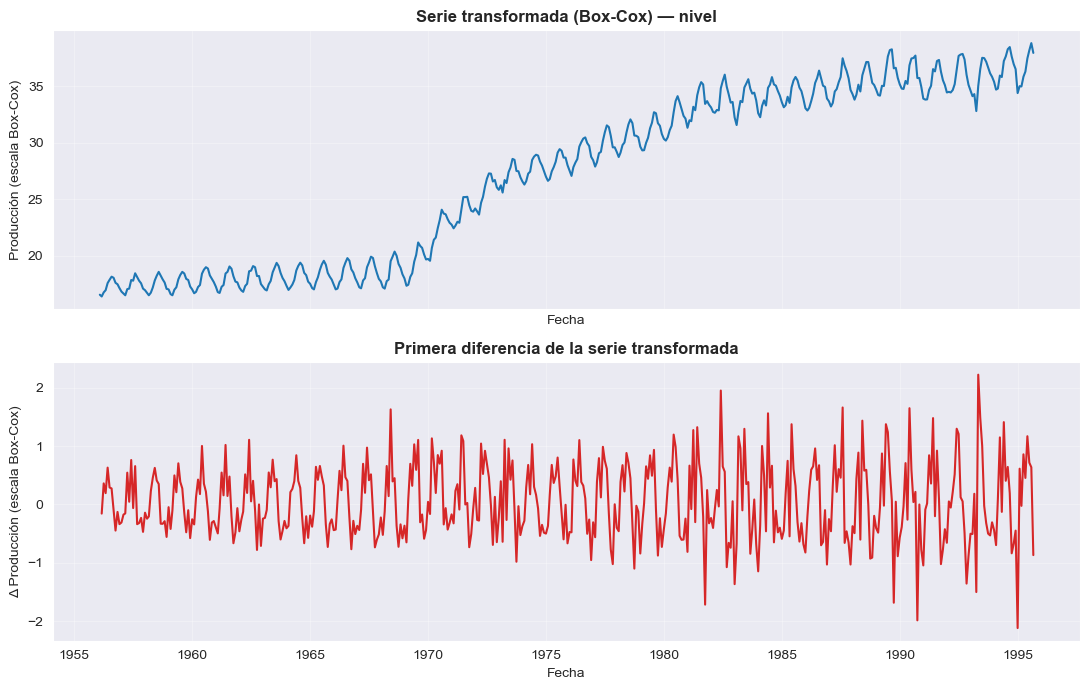

In [12]:
serie_gas_diferenciada = serie_gas_boxcox.diff(1)

fig, ejes = plt.subplots(2, 1, sharex=True, figsize=(11, 7))
ejes[0].plot(serie_gas_boxcox)
formatear_grafico(ejes[0], "Serie transformada (Box-Cox) — nivel", "Producción (escala Box-Cox)")
ejes[1].plot(serie_gas_diferenciada, color="tab:red")
formatear_grafico(ejes[1], "Primera diferencia de la serie transformada", "Δ Producción (escala Box-Cox)")
plt.tight_layout()
plt.show()

### 🔎 Interpretación

La serie en nivel muestra una tendencia creciente clara. La serie diferenciada oscila alrededor de un valor
constante cercano a cero, sin la tendencia visible en el panel superior: la diferenciación "quitó" la tendencia,
dejando principalmente la componente estacional y el ruido. El primer valor de la serie diferenciada es `NaN`
(no existe $y_0$ anterior a $y_1$) — es esperable y normalmente se descarta antes de modelar.

### 🧠 Para pensar

1. Si diferenciamos dos veces (`.diff().diff()`) una serie que ya era estacionaria en su primera diferencia,
   ¿qué esperaría que le pase a la varianza de la serie resultante?
2. ¿Por qué tiene más sentido diferenciar *después* de aplicar Box-Cox, y no antes?

### ✍️ Ejercicio

Calcule la diferencia estacional de periodo 12 (`serie_gas_boxcox.diff(12)`) en lugar de la diferencia simple.
Grafíquela y compare: ¿desaparece mejor el patrón estacional que con `diff(1)`?

## 9. Efectos de calendario

### Concepto

En muchas series reales el comportamiento cambia según el calendario, sin que eso sea tendencia ni estacionalidad
"pura": fines de semana, festivos, cierres de mes o de trimestre, o el número de días hábiles de cada mes. Estas
variables pueden construirse a partir del índice temporal y usarse **como variables exógenas / explicativas** en
modelos de regresión, ARIMAX o de machine learning.

| Efecto | Variable típica |
|---|---|
| Fin de semana | `serie.index.dayofweek.isin([5, 6])` |
| Festivo | `serie.index.isin(holidays.Colombia(...))` |
| Fin de mes | `serie.index.is_month_end` |
| Fin de trimestre | `serie.index.is_quarter_end` |
| Días del mes | `serie.index.days_in_month` |

### Ejemplo

In [13]:
serie_cal = serie_ltc.copy()

serie_cal["dia_semana"] = serie_cal.index.dayofweek  # 0 = lunes, 6 = domingo
serie_cal["es_fin_de_semana"] = serie_cal["dia_semana"].isin([5, 6]).astype(int)

# ⚠️ El objeto `holidays.Colombia()` sin argumentos no trae ningún año precargado: hay que indicar
# explícitamente el rango de años que cubre la serie, o no tendrá ninguna fecha que ofrecer.
anios = range(serie_cal.index.year.min(), serie_cal.index.year.max() + 1)
festivos_colombia = holidays.Colombia(years=anios)

# ⚠️ Un segundo problema, más sutil: las claves de `festivos_colombia` son objetos `datetime.date`,
# mientras que `serie_cal.index` es un `DatetimeIndex` (dtype datetime64[ns]). `Index.isin()` compara
# tipos de dato, no solo valores calendario, así que comparar directamente contra el diccionario de
# festivos devuelve 0 coincidencias aunque las fechas SÍ coincidan. Hay que convertir las claves a
# `Timestamp` explícitamente antes de comparar.
fechas_festivas = pd.to_datetime(list(festivos_colombia.keys()))
serie_cal["es_festivo"] = serie_cal.index.isin(fechas_festivas).astype(int)

serie_cal["fin_de_mes"] = serie_cal.index.is_month_end.astype(int)
serie_cal["fin_de_trimestre"] = serie_cal.index.is_quarter_end.astype(int)
serie_cal["dias_del_mes"] = serie_cal.index.days_in_month

print(f"Festivos detectados en el periodo: {serie_cal['es_festivo'].sum()} de {len(serie_cal)} días.")
serie_cal.head()

Festivos detectados en el periodo: 107 de 2192 días.


,Open,dia_semana,es_fin_de_semana,es_festivo,fin_de_mes,fin_de_trimestre,dias_del_mes
2020-01-01,60.238708,2,0,1,0,0,31
2020-01-02,58.103479,3,0,0,0,0,31
2020-01-03,60.199041,4,0,0,0,0,31
2020-01-04,61.547897,5,1,0,0,0,31
2020-01-05,57.354539,6,1,0,0,0,31


> ⚠️ **Cuidado — dos errores frecuentes, y ninguno lanza una excepción**
> 1. `holidays.Colombia()` (sin el argumento `years`) crea un calendario de festivos **vacío**: la librería solo
>    genera las fechas de los años que se le piden explícitamente.
> 2. Incluso con `years` bien especificado, comparar directamente `indice.isin(festivos_colombia)` da **0**
>    coincidencias: las claves del objeto `holidays` son `datetime.date`, mientras que el índice es un
>    `DatetimeIndex` (`datetime64[ns]`). `Index.isin()` no coacciona ese tipo de dato automáticamente, así que
>    compara "manzanas con peras" y nunca encuentra coincidencias.
>
> Ambos fallan **sin ningún error ni advertencia** — el código corre, produce una columna de ceros, y solo se
> nota comparando contra un cálculo independiente (como se hizo aquí). La solución: fijar `years=...` y convertir
> las claves con `pd.to_datetime(list(festivos.keys()))` antes de comparar.

Precio promedio en días no festivos: 25.17
Precio promedio en días festivos:    24.97


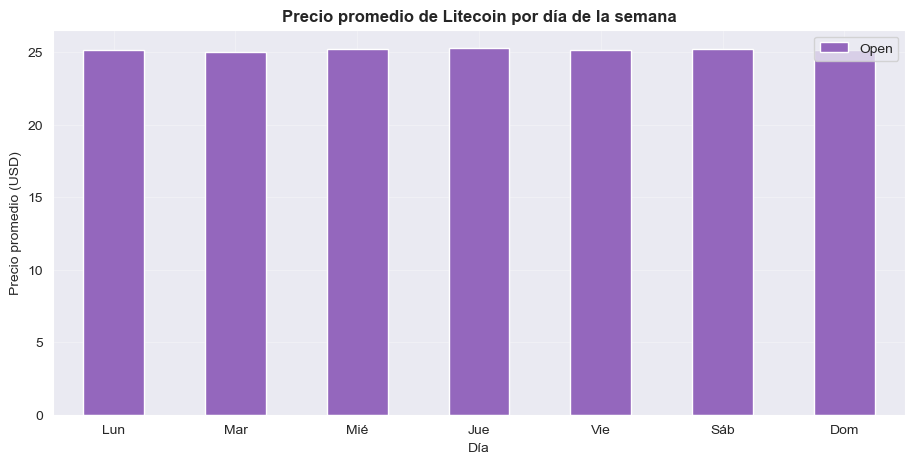

In [14]:
promedio_habil = serie_cal.loc[serie_cal["es_festivo"] == 0, "Open"].mean()
promedio_festivo = serie_cal.loc[serie_cal["es_festivo"] == 1, "Open"].mean()
print(f"Precio promedio en días no festivos: {promedio_habil:.2f}")
print(f"Precio promedio en días festivos:    {promedio_festivo:.2f}")

fig, ax = plt.subplots()
serie_cal.groupby("dia_semana")["Open"].mean().plot(kind="bar", ax=ax, color="tab:purple")
ax.set_xticklabels(["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"], rotation=0)
formatear_grafico(ax, "Precio promedio de Litecoin por día de la semana", "Precio promedio (USD)", "Día")
plt.show()

### 🔎 Interpretación

Con el rango de años especificado y las claves convertidas a `Timestamp`, ahora sí se identifican festivos
colombianos dentro del periodo (compare con el conteo de `0` que se obtendría con cualquiera de los dos errores
anteriores). Litecoin cotiza todos los
días del año (no respeta el calendario bursátil colombiano), por lo que aquí el efecto festivo/fin de semana es
más una demostración metodológica que un hallazgo económico; en una serie de ventas, tráfico o consultas
médicas locales, este mismo procedimiento sí suele mostrar diferencias sustantivas.

### Efecto del número de días del mes al agregar

Al pasar de diario a mensual, los meses no tienen la misma cantidad de días. Esto puede distorsionar
comparaciones si no se controla.

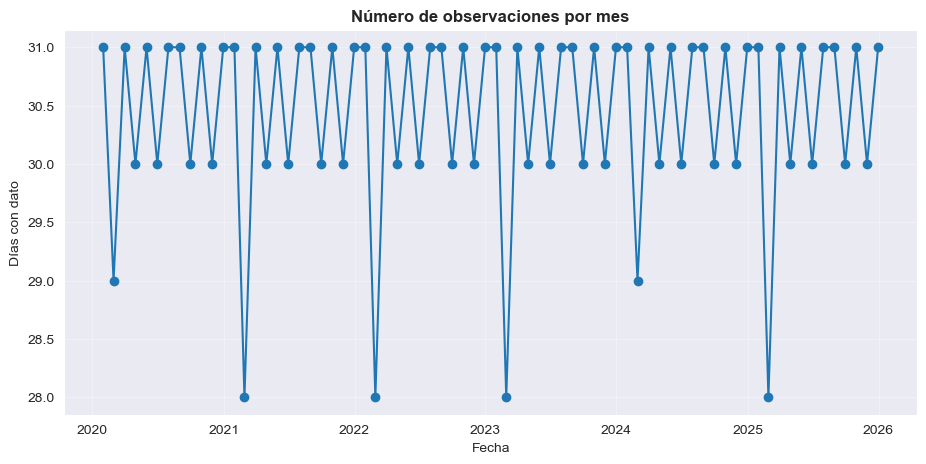

In [15]:
conteo_mensual = serie_cal["Open"].resample("ME").count()

fig, ax = plt.subplots()
ax.plot(conteo_mensual, marker="o")
formatear_grafico(ax, "Número de observaciones por mes", "Días con dato", )
plt.show()

### 🔎 Interpretación

Los meses de 28-31 días generan conteos ligeramente distintos incluso sin ningún dato faltante. Si la variable
agregada fuera, por ejemplo, ventas totales (`.sum()`), un mes de 31 días tendría una ventaja estructural sobre
uno de 28 días que nada tiene que ver con el desempeño real del negocio — otra razón para documentar siempre la
función de agregación usada (sección 6).

> ⚠️ **Cuidado**
> Los efectos de calendario no son tendencia ni estacionalidad clásica; son variaciones estructurales asociadas
> al calendario. Si no se controlan, un modelo puede interpretar un patrón de calendario como si fuera
> estacionalidad real, o inflar la varianza residual.

### 🧠 Para pensar

1. Ninguno de los dos errores de la caja de advertencia genera una excepción. ¿Qué le enseña esto sobre validar
   salidas de librerías en lugar de asumir que "si no hay error, está bien"? ¿Cómo lo habría detectado si no
   hubiera calculado el conteo de festivos explícitamente?
2. En una serie de ventas de un comercio físico colombiano, ¿esperaría un efecto de festivo más fuerte que en
   Litecoin? ¿Por qué?

### ✍️ Ejercicio

Agregue a `serie_cal` una variable `es_inicio_de_mes` usando `serie_cal.index.is_month_start`, y calcule el
precio promedio de apertura en los primeros días del mes frente al resto. ¿Observa alguna diferencia?

## 10. Datos faltantes en series de tiempo

### Concepto

Antes de imputar, hay que distinguir con cuidado **cuatro situaciones** que a simple vista pueden confundirse:

| Situación | ¿Qué es? | Ejemplo |
|---|---|---|
| Observación realmente faltante | El evento ocurrió pero no se registró | El sensor falló un día |
| Fecha ausente del índice | La fecha ni siquiera aparece en los datos | Un día sin ninguna fila en la tabla |
| `NaN` explícito | La fecha existe, pero el valor es nulo | Se registró la fila, sin el dato |
| Cero real | El valor observado es efectivamente 0 | Cero ventas ese día (dato válido) |

La sección 3 ya mostró que forzar una frecuencia regular con `asfreq()` convierte "fechas ausentes del índice" en
"`NaN` explícitos" — son cosas distintas y conviene no confundirlas con un cero real.

### Datos de ejemplo: AirPassengers con datos faltantes simulados

Usamos la serie clásica de pasajeros aéreos (Box, Jenkins y Reinsel, 1949-1960). Se incluye una copia local de
los 144 valores para que el notebook no dependa de una conexión a internet ni de la disponibilidad del
repositorio de datasets de R.

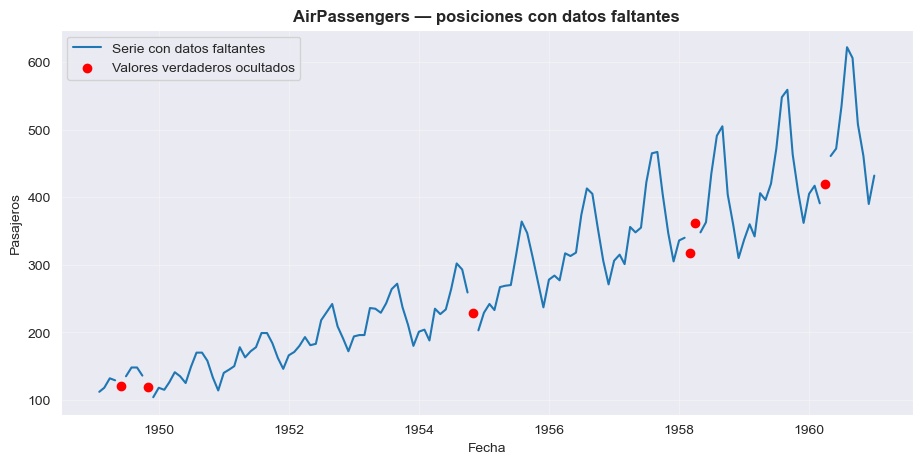

In [16]:
AIR_PASSENGERS = [112, 118, 132, 129, 121, 135, 148, 148, 136, 119, 104, 118, 115, 126, 141, 135, 125, 149, 170, 170, 158, 133, 114, 140, 145, 150, 178, 163, 172, 178, 199, 199, 184, 162, 146, 166, 171, 180, 193, 181, 183, 218, 230, 242, 209, 191, 172, 194, 196, 196, 236, 235, 229, 243, 264, 272, 237, 211, 180, 201, 204, 188, 235, 227, 234, 264, 302, 293, 259, 229, 203, 229, 242, 233, 267, 269, 270, 315, 364, 347, 312, 274, 237, 278, 284, 277, 317, 313, 318, 374, 413, 405, 355, 306, 271, 306, 315, 301, 356, 348, 355, 422, 465, 467, 404, 347, 305, 336, 340, 318, 362, 348, 363, 435, 491, 505, 404, 359, 310, 337, 360, 342, 406, 396, 420, 472, 548, 559, 463, 407, 362, 405, 417, 391, 419, 461, 472, 535, 622, 606, 508, 461, 390, 432]

fechas_pasajeros = pd.date_range(start="1949-01-01", periods=len(AIR_PASSENGERS), freq="ME")
pasajeros = pd.Series(AIR_PASSENGERS, index=fechas_pasajeros, name="pasajeros")

# Se ocultan artificialmente algunas observaciones (incluye un hueco de 2 datos consecutivos)
posiciones_faltantes = [4, 9, 69, 109, 110, 134]
pasajeros_con_huecos = pasajeros.copy()
pasajeros_con_huecos.iloc[posiciones_faltantes] = np.nan

fig, ax = plt.subplots()
ax.plot(pasajeros_con_huecos, label="Serie con datos faltantes")
ax.scatter(pasajeros.index[posiciones_faltantes], pasajeros.iloc[posiciones_faltantes],
           color="red", zorder=5, label="Valores verdaderos ocultados")
formatear_grafico(ax, "AirPassengers — posiciones con datos faltantes", "Pasajeros")
plt.show()

In [17]:
print("Valores faltantes por posición:")
print(pasajeros_con_huecos.isna().sum(), "de", len(pasajeros_con_huecos), "observaciones totales")
print("\nFechas con dato faltante:")
print(pasajeros_con_huecos[pasajeros_con_huecos.isna()].index.tolist())

Valores faltantes por posición:
6 de 144 observaciones totales

Fechas con dato faltante:
[Timestamp('1949-05-31 00:00:00'), Timestamp('1949-10-31 00:00:00'), Timestamp('1954-10-31 00:00:00'), Timestamp('1958-02-28 00:00:00'), Timestamp('1958-03-31 00:00:00'), Timestamp('1960-03-31 00:00:00')]


### 🔎 Interpretación

`isna().sum()` cuenta 6 valores faltantes. Todas las fechas siguen presentes en el índice (a diferencia del caso
de la sección 3): aquí simulamos el escenario de "observación realmente faltante", con la fecha registrada pero
el valor nulo. Los puntos rojos marcan los valores verdaderos que fueron ocultados — los usaremos más adelante
para evaluar objetivamente qué tan bien reconstruye cada método de imputación esos valores.

### 🧠 Para pensar

1. Si en lugar de ver `NaN` viera un `0` en una serie de pasajeros mensuales, ¿asumiría automáticamente que fue
   un mes sin vuelos, o sospecharía de un error de registro?
2. ¿Qué método usaría para detectar fechas ausentes del índice en una serie que se supone diaria?

### ✍️ Ejercicio

Sobre `serie_gas` (sección 7), verifique con `pd.infer_freq()` si tiene una frecuencia mensual regular y con
`.isna().sum()` si tiene datos faltantes. Comente el resultado.

## 11. Métodos de imputación

### Concepto general

Imputar es reemplazar los valores faltantes por una estimación razonable, para poder usar técnicas que no
admiten `NaN` (como la mayoría de modelos ARIMA/ML). No existe un método universalmente superior: la elección
depende de la naturaleza de la serie y de cuántos datos consecutivos faltan.

> ⚠️ **Cuidado — fuga de información (data leakage)**
> Algunos métodos (interpolación, relleno hacia atrás / *backward fill*, suavizado que mira ambos lados) usan
> información de observaciones **futuras** respecto al dato faltante. Eso está bien para reconstruir un historial
> ya cerrado (como en este ejercicio), pero es **incorrecto** si se va a evaluar un modelo predictivo: imputar
> usando el futuro antes de separar entrenamiento y prueba filtra información que el modelo nunca tendría
> disponible en producción. La imputación (igual que cualquier transformación) debe ajustarse **solo** con el
> conjunto de entrenamiento y aplicarse después, respetando el orden temporal.

A continuación se compara cada método con la estructura: **concepto → código → gráfica → interpretación →
ventajas → limitaciones**, todos aplicados sobre `pasajeros_con_huecos`.

---

### 11.1 Imputación por la media

**Concepto:** reemplaza cada faltante por la media de todos los valores observados. Es el método más simple e
ignora por completo la posición temporal del dato.

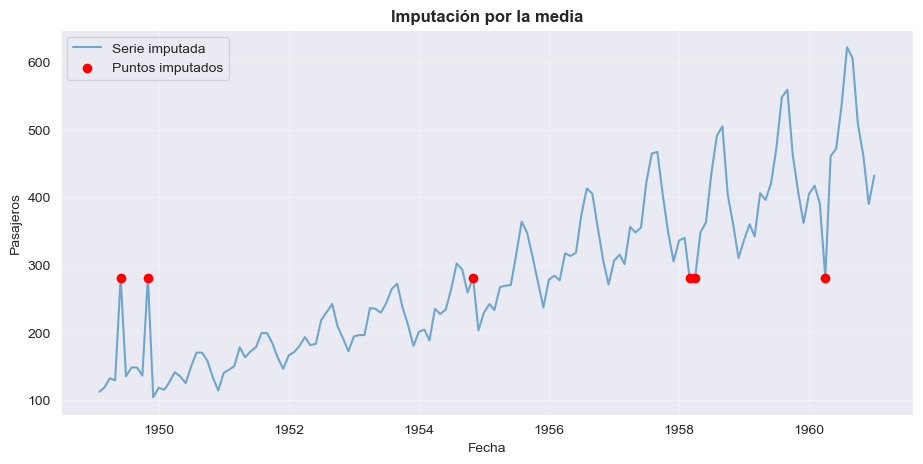

In [18]:
imputado_media = pasajeros_con_huecos.fillna(pasajeros_con_huecos.mean())

fig, ax = plt.subplots()
ax.plot(imputado_media, label="Serie imputada", alpha=0.6)
ax.scatter(pasajeros.index[posiciones_faltantes], imputado_media.iloc[posiciones_faltantes],
           color="red", zorder=5, label="Puntos imputados")
formatear_grafico(ax, "Imputación por la media", "Pasajeros")
plt.show()

**🔎 Interpretación:** los puntos imputados (rojos) quedan todos en el mismo valor horizontal (la media global),
ignorando que la serie tiene tendencia y estacionalidad. Es visualmente evidente que no encajan con el patrón
del resto de la serie.

**Ventajas:** trivial de implementar; no requiere ningún supuesto sobre el orden temporal.
**Limitaciones:** ignora tendencia, estacionalidad y toda la dependencia temporal; distorsiona la varianza de la
serie (la reduce artificialmente); es la peor opción cuando la serie no es aproximadamente constante.

---

### 11.2 LOCF — *Last Observation Carried Forward*

**Concepto:** reemplaza cada faltante por el último valor observado antes de él (`.ffill()`). Es un método
**causal**: solo usa información pasada, por lo que no genera fuga de información hacia adelante.

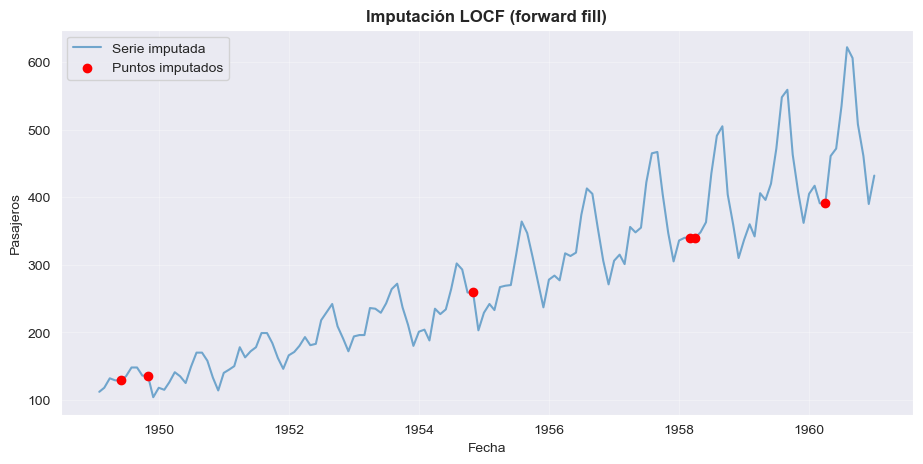

In [19]:
imputado_locf = pasajeros_con_huecos.ffill()

fig, ax = plt.subplots()
ax.plot(imputado_locf, label="Serie imputada", alpha=0.6)
ax.scatter(pasajeros.index[posiciones_faltantes], imputado_locf.iloc[posiciones_faltantes],
           color="red", zorder=5, label="Puntos imputados")
formatear_grafico(ax, "Imputación LOCF (forward fill)", "Pasajeros")
plt.show()

**🔎 Interpretación:** en el hueco de dos meses consecutivos (posiciones 109-110), ambos quedan "congelados" en
el mismo valor del mes anterior — razonable si la serie cambia lento, pero problemático si hay una tendencia
fuerte dentro del hueco (como es el caso aquí, en plena temporada de crecimiento).

**Ventajas:** es causal (no usa el futuro), por lo que es seguro de usar antes de un train/test split; simple e
intuitivo para variables de "nivel" (como un inventario).
**Limitaciones:** subestima sistemáticamente la tendencia dentro de huecos largos; no funciona para el primer
valor de la serie si este es faltante (no hay observación previa que "cargar hacia adelante").

---

### 11.3 Interpolación lineal

**Concepto:** estima cada faltante trazando una línea recta entre el último valor observado antes del hueco y el
primer valor observado después. A diferencia de LOCF, **sí usa información futura** respecto al dato faltante.

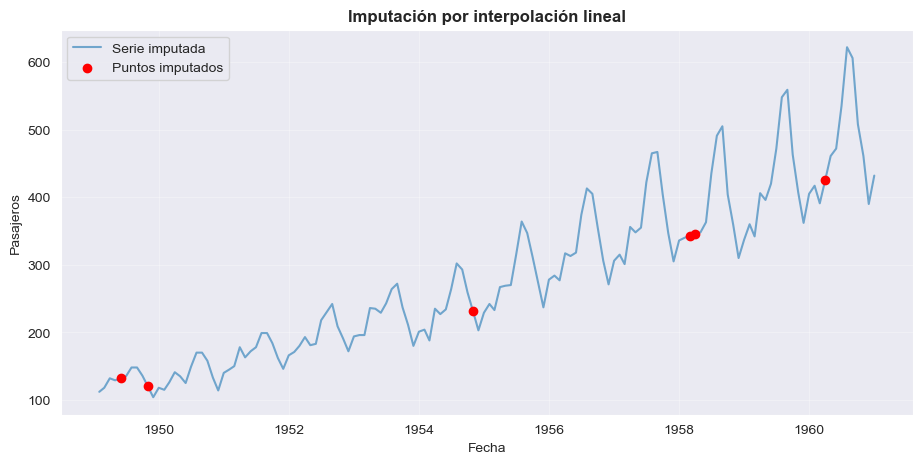

In [20]:
imputado_interpolacion = pasajeros_con_huecos.interpolate(method="linear")

fig, ax = plt.subplots()
ax.plot(imputado_interpolacion, label="Serie imputada", alpha=0.6)
ax.scatter(pasajeros.index[posiciones_faltantes], imputado_interpolacion.iloc[posiciones_faltantes],
           color="red", zorder=5, label="Puntos imputados")
formatear_grafico(ax, "Imputación por interpolación lineal", "Pasajeros")
plt.show()

**🔎 Interpretación:** en el hueco de dos meses, la interpolación traza una línea recta entre el valor previo y
el siguiente, lo que suele verse más natural que LOCF cuando hay tendencia dentro del hueco.

**Ventajas:** captura tendencias locales mucho mejor que la media o LOCF; buen balance entre simplicidad y
realismo para huecos cortos.
**Limitaciones:** usa el valor *futuro* al hueco — no es seguro usarla antes de un train/test split sin cuidado;
para huecos largos, una línea recta puede ignorar patrones estacionales dentro del hueco.

---

### 11.4 Media móvil (suavizado exponencial)

**Concepto:** reemplaza cada faltante por un promedio ponderado de observaciones recientes, dando más peso a las
más cercanas (`.ewm(span=...).mean()`). Tal como se usa aquí (calculada sobre la serie con huecos y aplicada solo
hacia adelante), es un método causal.

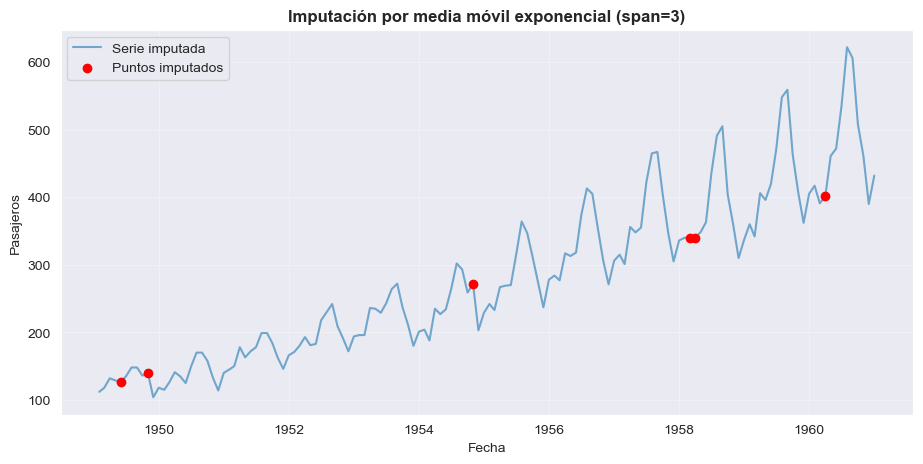

In [21]:
imputado_media_movil = pasajeros_con_huecos.fillna(pasajeros_con_huecos.ewm(span=3, adjust=False).mean())

fig, ax = plt.subplots()
ax.plot(imputado_media_movil, label="Serie imputada", alpha=0.6)
ax.scatter(pasajeros.index[posiciones_faltantes], imputado_media_movil.iloc[posiciones_faltantes],
           color="red", zorder=5, label="Puntos imputados")
formatear_grafico(ax, "Imputación por media móvil exponencial (span=3)", "Pasajeros")
plt.show()

**🔎 Interpretación:** suaviza menos abruptamente que LOCF porque promedia varias observaciones recientes en vez
de fijarse solo en la última, pero sigue sin capturar bien un cambio de tendencia rápido dentro del hueco.

**Ventajas:** es causal; suaviza ruido de corto plazo mejor que LOCF puro.
**Limitaciones:** el resultado depende de la ventana (`span`) elegida; sigue sin usar información estacional.

---

### 11.5 Modelo ARIMA

**Concepto:** ajusta un modelo ARIMA sobre la serie con huecos (`statsmodels` maneja los `NaN` internamente vía
filtro de Kalman) y usa las predicciones internas del modelo para rellenar los faltantes. Es el método más
sofisticado de los cinco porque explota la estructura de autocorrelación completa de la serie.

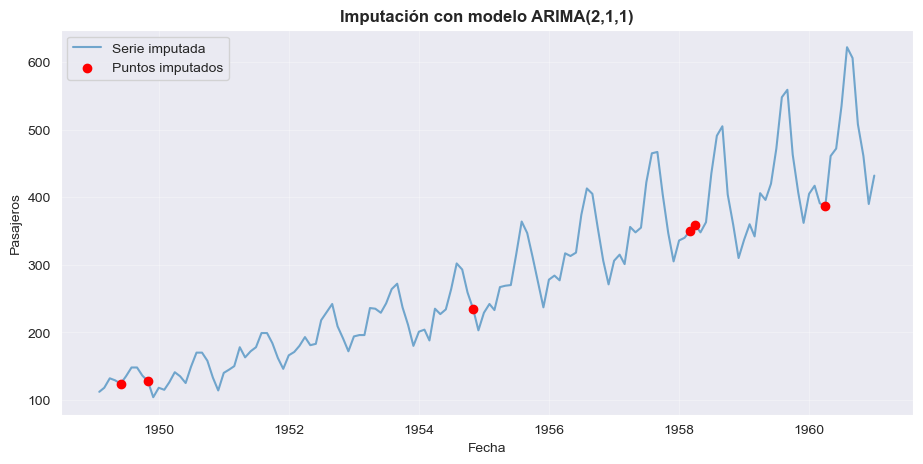

In [22]:
modelo_arima = ARIMA(pasajeros_con_huecos, order=(2, 1, 1)).fit()
predicho_arima = pd.Series(modelo_arima.predict(start=0, end=len(pasajeros_con_huecos) - 1).values,
                            index=pasajeros_con_huecos.index)
imputado_arima = pasajeros_con_huecos.fillna(predicho_arima)

fig, ax = plt.subplots()
ax.plot(imputado_arima, label="Serie imputada", alpha=0.6)
ax.scatter(pasajeros.index[posiciones_faltantes], imputado_arima.iloc[posiciones_faltantes],
           color="red", zorder=5, label="Puntos imputados")
formatear_grafico(ax, "Imputación con modelo ARIMA(2,1,1)", "Pasajeros")
plt.show()

**🔎 Interpretación:** al aprovechar la autocorrelación de la serie completa, el ARIMA suele producir valores más
cercanos al patrón general que los métodos simples, incluso en el hueco de dos meses consecutivos.

**Ventajas:** modela explícitamente la dependencia temporal; se adapta bien cuando hay autocorrelación fuerte.
**Limitaciones:** requiere elegir un orden `(p, d, q)` razonable; computacionalmente más costoso; usar
`.predict()` in-sample también puede incorporar información posterior al ajustar el modelo sobre la serie
completa — el mismo cuidado de fuga de información aplica aquí si el objetivo final es evaluar un pronóstico.

### 🧠 Para pensar

1. ¿La imputación por la media conserva la dependencia temporal de la serie? ¿Por qué sí o por qué no?
2. ¿Podría la interpolación lineal usar información futura respecto al dato que está imputando? ¿En qué casos
   eso sería un problema?
3. De los cinco métodos, ¿cuál usaría para imputar el **primer** dato de una serie, si está faltante? ¿Por qué
   LOCF no sirve en ese caso particular?

### ✍️ Ejercicio

Repita la imputación LOCF pero usando `.bfill()` (relleno hacia atrás) en lugar de `.ffill()`. Grafique ambas
series imputadas superpuestas. ¿En qué se diferencian, y cuál de las dos usa información futura?

## 12. Evaluación objetiva de los métodos de imputación

### Concepto

Las gráficas anteriores dan intuición, pero no permiten comparar métodos de forma objetiva. El experimento
estándar es:

1. Partir de una serie **completa** (sin faltantes reales).
2. Ocultar artificialmente un subconjunto de observaciones (aquí, 15% elegido al azar con semilla fija).
3. Aplicar cada método de imputación sobre la serie con huecos.
4. Comparar el valor imputado contra el valor verdadero que se ocultó, usando **MAE** (error absoluto medio) y
   **RMSE** (raíz del error cuadrático medio).

Esto sí permite decir, para esta serie en particular, qué método se acercó más a la realidad.

In [23]:
np.random.seed(42)
n_obs = len(pasajeros)
n_ocultos = int(n_obs * 0.15)

# Se excluyen los extremos para que todos los métodos (incluida la interpolación) tengan vecinos válidos.
posiciones_evaluacion = np.sort(
    np.random.choice(np.arange(3, n_obs - 3), size=n_ocultos, replace=False)
)

serie_evaluacion = pasajeros.copy()
serie_evaluacion.iloc[posiciones_evaluacion] = np.nan
valores_verdaderos = pasajeros.iloc[posiciones_evaluacion]

print(f"Se ocultaron {n_ocultos} de {n_obs} observaciones ({n_ocultos/n_obs:.0%}) para evaluar la imputación.")

Se ocultaron 21 de 144 observaciones (15%) para evaluar la imputación.


In [24]:
modelo_arima_eval = ARIMA(serie_evaluacion, order=(2, 1, 1)).fit()
predicho_arima_eval = pd.Series(
    modelo_arima_eval.predict(start=0, end=n_obs - 1).values, index=serie_evaluacion.index
)

metodos_imputacion = {
    "Media": serie_evaluacion.fillna(serie_evaluacion.mean()),
    "LOCF": serie_evaluacion.ffill(),
    "Interpolación lineal": serie_evaluacion.interpolate(method="linear"),
    "Media móvil (ewm span=3)": serie_evaluacion.fillna(serie_evaluacion.ewm(span=3, adjust=False).mean()),
    "ARIMA(2,1,1)": serie_evaluacion.fillna(predicho_arima_eval),
}

resultados = []
for nombre, serie_imputada in metodos_imputacion.items():
    predicho = serie_imputada.iloc[posiciones_evaluacion]
    mae = np.mean(np.abs(predicho - valores_verdaderos))
    rmse = np.sqrt(np.mean((predicho - valores_verdaderos) ** 2))
    resultados.append({"Método": nombre, "MAE": round(mae, 2), "RMSE": round(rmse, 2)})

tabla_resultados = pd.DataFrame(resultados).sort_values("RMSE").reset_index(drop=True)
tabla_resultados

,Método,MAE,RMSE
0,Interpolación lineal,14.76,19.52
1,LOCF,17.57,23.98
2,"ARIMA(2,1,1)",17.42,24.10
3,Media móvil (ewm span=3),19.62,25.32
4,Media,77.59,87.29


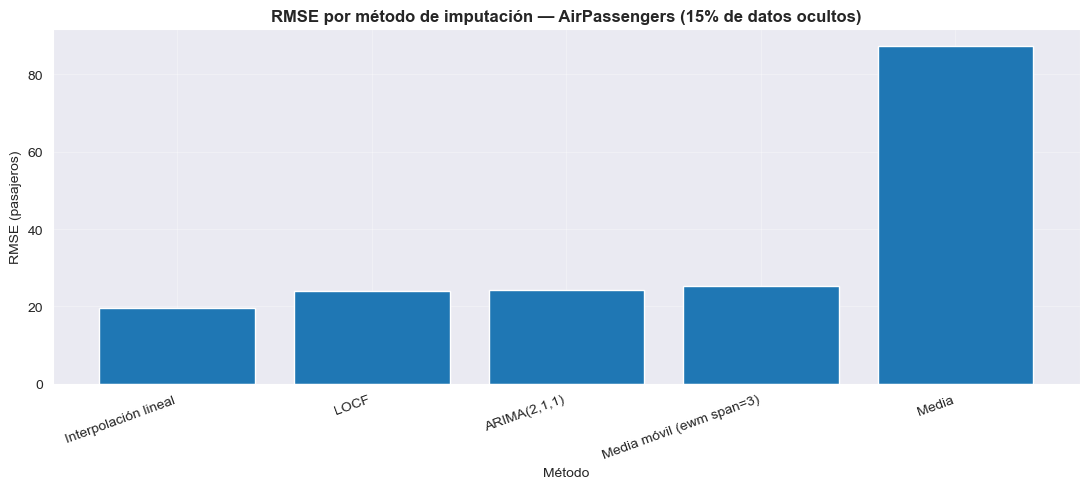

In [25]:
fig, ax = plt.subplots()
ax.bar(tabla_resultados["Método"], tabla_resultados["RMSE"], color="tab:blue")
formatear_grafico(ax, "RMSE por método de imputación — AirPassengers (15% de datos ocultos)", "RMSE (pasajeros)", "Método")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### 🔎 Interpretación

Para esta serie —con tendencia y estacionalidad marcadas—, los métodos que usan estructura temporal (ARIMA,
interpolación) superan claramente a la media global. **Esto no significa que ARIMA sea siempre el mejor
método**: es el mejor *para esta serie, con este patrón de datos faltantes, ocultando el 15% al azar*. En una
serie con mucho ruido y sin tendencia clara, la ventaja de ARIMA sobre la interpolación sería probablemente
menor. La única forma confiable de elegir un método es replicar este mismo experimento sobre la serie real que
se esté trabajando.

> ⚠️ **Cuidado**
> Este experimento ocultó datos **al azar**, lo que favorece a los métodos que interpolan usando ambos lados del
> hueco. Si en la práctica los datos faltantes tienden a agruparse en bloques largos (por ejemplo, un sensor
> apagado dos semanas), conviene repetir el experimento ocultando bloques contiguos en lugar de puntos aislados,
> porque el desempeño relativo de los métodos puede cambiar.

### 🧠 Para pensar

1. ¿Por qué el experimento excluye los primeros y últimos 3 puntos de la serie al elegir posiciones a ocultar?
2. Si en lugar de ocultar puntos aislados se ocultara un bloque continuo de 12 meses, ¿qué método esperaría que
   se deteriore más? ¿Por qué?

### ✍️ Ejercicio

Repita el experimento con un porcentaje de datos ocultos mayor (30%) y compare la tabla de resultados. ¿Cambia
el orden de los métodos? ¿Qué le dice eso sobre la robustez de cada método frente a la cantidad de datos
faltantes?

## 13. Recapitulación de riesgos metodológicos

A lo largo del cuadernillo aparecieron varias advertencias ⚠️. Antes de modelar, revise que ninguna de ellas
aplique sin haber sido considerada:

- **Agregación excesiva:** reducir demasiado la frecuencia puede borrar el patrón que se quiere estudiar.
- **Función de agregación incorrecta:** `.mean()` en variables de flujo (ventas) subestima el total; `.sum()` en
  variables de nivel (inventario) no tiene sentido.
- **`asfreq()` vs `resample()`:** no son intercambiables; confundirlos cambia el significado de los datos.
- **Box-Cox con valores no positivos:** la transformación no está definida; desplazar los datos para forzarla es
  una decisión de modelado que debe justificarse, no un paso automático.
- **Sobre-diferenciación:** diferenciar una serie ya estacionaria introduce autocorrelación artificial.
- **Festivos u otras variables de calendario mal construidas:** errores silenciosos (`holidays.Colombia()` sin
  `years`, o comparar `datetime.date` contra un `DatetimeIndex` con `.isin()`) pueden pasar completamente
  inadvertidos si no se valida el resultado contra un cálculo independiente.
- **Imputación con información futura:** interpolación, `bfill()` y suavizados bidireccionales usan el futuro
  respecto al dato faltante — válido para reconstruir un histórico cerrado, riesgoso para evaluar modelos
  predictivos.
- **Imputar antes de separar entrenamiento y prueba:** ajustar la imputación (media, modelo, etc.) sobre todo el
  conjunto de datos, incluyendo lo que después será "prueba", filtra información y produce métricas de
  desempeño optimistas de forma artificial.

> ⚠️ **Regla general**
> Para cualquier flujo predictivo, toda transformación e imputación debe **ajustarse solo con datos de
> entrenamiento** y aplicarse después hacia adelante, respetando el orden temporal — nunca al revés.

## 14. ✅ Lo que aprendimos

- Un índice temporal correcto (`DatetimeIndex`, ordenado, sin duplicados, con frecuencia verificable) es la base
  de cualquier análisis de series de tiempo.
- `resample()` agrega datos con una función explícita; `asfreq()` solo reindexa y selecciona, sin agregar.
- La función de agregación debe elegirse según la naturaleza de la variable (flujo → suma, nivel → último valor
  o media, extremos → máximo/mínimo).
- Box-Cox estabiliza la varianza cuando esta crece con el nivel de la serie, y requiere datos estrictamente
  positivos; el índice de fechas debe conservarse después de transformar.
- Diferenciar ataca la tendencia (no estacionariedad en media), no la varianza; no debe aplicarse
  automáticamente.
- Las variables de calendario (día de semana, festivos, fin de mes/trimestre) capturan efectos estructurales que
  no son tendencia ni estacionalidad clásica, y pueden usarse como variables exógenas.
- Es indispensable distinguir entre observación faltante, fecha ausente del índice, `NaN` explícito y cero real.
- No existe un método de imputación universalmente superior: media, LOCF, interpolación, media móvil y ARIMA
  tienen ventajas y limitaciones distintas, y su desempeño relativo se puede medir con MAE/RMSE.
- Algunos métodos de imputación usan información futura respecto al dato faltante, lo que genera fuga de
  información si se usan antes de separar entrenamiento y prueba.

## 15. 📌 Buenas prácticas para preparar una serie temporal

- [ ] Revisar el tipo de dato del índice (`DatetimeIndex`).
- [ ] Ordenar cronológicamente (`sort_index()`).
- [ ] Verificar duplicados en el índice (`index.duplicated()`).
- [ ] Identificar la frecuencia (`pd.infer_freq()`) y forzarla explícitamente si es necesario (`asfreq()`).
- [ ] Detectar fechas ausentes del índice (al forzar la frecuencia, aparecen como `NaN`).
- [ ] Detectar valores faltantes explícitos (`isna().sum()`).
- [ ] Analizar si se necesita agregación y, si es así, elegir la función correcta para la variable.
- [ ] Evitar fuga de información: ajustar transformaciones e imputación solo con datos de entrenamiento.
- [ ] Documentar cada transformación realizada (frecuencia, función de agregación, λ de Box-Cox, orden de
      diferenciación, método de imputación) para que el análisis sea reproducible.

# 📝 Taller práctico

Trabajará con una serie **simulada** de ventas diarias de una tienda (no usada en las secciones anteriores), con
tendencia, estacionalidad semanal y algunos datos faltantes. La serie se genera con semilla fija para que todos
obtengan los mismos datos.

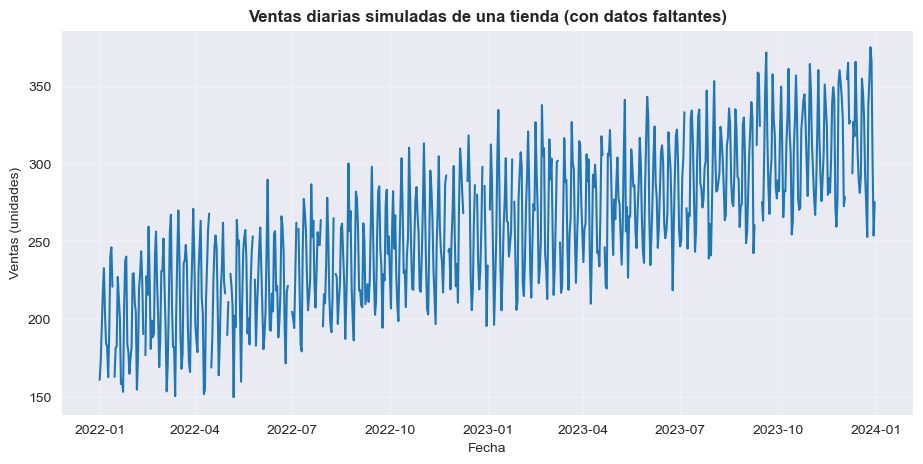

In [26]:
rng_taller = np.random.default_rng(7)
fechas_taller = pd.date_range("2022-01-01", periods=730, freq="D")

tendencia = np.linspace(200, 320, len(fechas_taller))
estacionalidad_semanal = 40 * np.sin(2 * np.pi * fechas_taller.dayofweek / 7)
ruido = rng_taller.normal(0, 15, len(fechas_taller))
ventas = np.clip(tendencia + estacionalidad_semanal + ruido, 0, None).round(1)

ventas_tienda = pd.Series(ventas, index=fechas_taller, name="ventas")

# Se ocultan artificialmente algunos días (fallas de registro simuladas)
posiciones_ocultas_taller = rng_taller.choice(np.arange(5, len(ventas_tienda) - 5), size=25, replace=False)
ventas_tienda_huecos = ventas_tienda.copy()
ventas_tienda_huecos.iloc[posiciones_ocultas_taller] = np.nan

fig, ax = plt.subplots()
ax.plot(ventas_tienda_huecos)
formatear_grafico(ax, "Ventas diarias simuladas de una tienda (con datos faltantes)", "Ventas (unidades)")
plt.show()

### Ejercicio 1 (básico) — Frecuencia e índice

Verifique que `ventas_tienda_huecos` tenga un `DatetimeIndex`, esté ordenada cronológicamente y no tenga fechas
duplicadas. Confirme con `pd.infer_freq()` cuál es su frecuencia.

In [27]:
# Ejercicio 1 — su código aquí

### Ejercicio 2 (básico-intermedio) — Remuestreo y elección de agregación

Convierta `ventas_tienda_huecos` a una serie semanal. Justifique en una celda de texto por qué eligió `.sum()`,
`.mean()` u otra función de agregación para esta variable en particular.

In [28]:
# Ejercicio 2 — su código aquí

### Ejercicio 3 (intermedio) — Detección e imputación

Cuente cuántos valores faltantes tiene `ventas_tienda_huecos` y en qué fechas ocurren. Impute la serie con al
menos dos métodos distintos (por ejemplo, interpolación lineal y LOCF) y grafique ambas series imputadas junto
con la original, marcando los puntos imputados.

In [29]:
# Ejercicio 3 — su código aquí

### Ejercicio 4 (aplicado) — Evaluación cuantitativa

`ventas_tienda` (sin huecos) contiene los valores verdaderos de las posiciones ocultadas en
`posiciones_ocultas_taller`. Replique el experimento de la sección 12: calcule MAE y RMSE para al menos tres
métodos de imputación sobre esas posiciones, y arme una tabla comparativa como la de esa sección.

In [30]:
# Ejercicio 4 — su código aquí

### Ejercicio 5 (reto) — Variables de calendario y transformación

Construya variables de calendario (día de semana, fin de semana, fin de mes) para `ventas_tienda`, y evalúe si el
promedio de ventas difiere entre fin de semana y días hábiles. Después, aplique la transformación de Box-Cox a
la serie (recuerde verificar la condición de positividad) y comente, en una celda de texto, si considera que
esta serie realmente necesitaba estabilización de varianza — justifique con base en lo observado en la gráfica
de la serie original.

In [31]:
# Ejercicio 5 — su código aquí